# Smart Retail Shelf Monitoring
## Phase 1: Training YOLOv8 on SKU110K Dataset
### DATA 690 - Applied Artificial Intelligence | UMBC
**Goal:** Fine-tune YOLOv8 on retail shelf images to detect
products and identify empty shelf regions.

In [ ]:
# Check GPU is available
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "No GPU")
!nvidia-smi

GPU Available: True
GPU Name: Tesla T4
Wed Apr 22 17:29:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------

In [ ]:
import shutil

shutil.rmtree('/content/SKU-110k-1', ignore_errors=True)
print("Old dataset removed")

Old dataset removed


In [ ]:
# Install Ultralytics YOLOv8
!pip install ultralytics -q
!pip install roboflow --q

# Verify installation
from ultralytics import YOLO
print("YOLOv8 installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 installed successfully!


In [ ]:
# Mount Google Drive to save model weights
from google.colab import drive
drive.mount('/content/drive')

# Create project folder
import os
os.makedirs('/content/drive/MyDrive/SmartShelf_Project', exist_ok=True)
print("Project folder ready!")

Mounted at /content/drive
Project folder ready!


In [ ]:
# Download SKU110K dataset (already formatted for YOLOv8)
# Sign up free at roboflow.com to get your API key

from roboflow import Roboflow

# Replace "your_api_key" with your actual Roboflow API key
rf = Roboflow(api_key="rzUECexAQEfVYvX39UyM")
project = rf.workspace("tilakrajs-workspace").project("smart-retail-shelf-monitoring")
dataset = project.version(1).download("yolov8")

print("Dataset downloaded!")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Smart-Retail-Shelf-Monitoring-1 in yolov8:: 100%|██████████| 20001/20001 [01:12<00:00, 276.82it/s] 


Dataset downloaded!
Dataset location: /content/Smart-Retail-Shelf-Monitoring-1


In [ ]:
# Check dataset folders and image counts
import os

dataset_path = dataset.location
print("Dataset Path:", dataset_path)

for split in ['train', 'valid', 'test']:
    img_path = os.path.join(dataset_path, split, 'images')
    if os.path.exists(img_path):
        count = len(os.listdir(img_path))
        print(f"{split} images: {count}")

Dataset Path: /content/Smart-Retail-Shelf-Monitoring-1
train images: 6998
valid images: 2000
test images: 1000


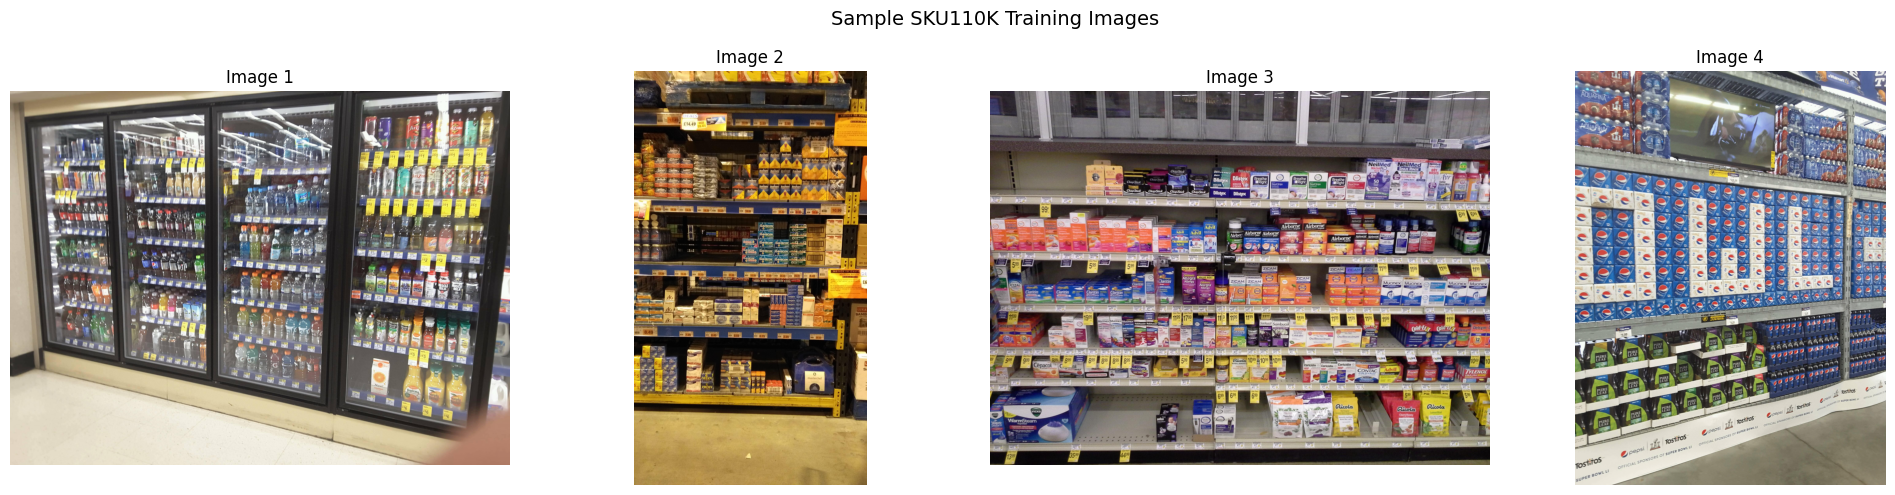

Sample images saved to Google Drive!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random

# Show 4 random training images
train_img_path = os.path.join(dataset.location, 'train', 'images')
images = random.sample(os.listdir(train_img_path), 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Sample SKU110K Training Images', fontsize=14)

for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(train_img_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f'Image {i+1}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SmartShelf_Project/sample_images.png')
plt.show()
print("Sample images saved to Google Drive!")

In [ ]:
from ultralytics import YOLO

# Load YOLOv8 small model pretrained on COCO
# 'yolov8s.pt' = small, good balance of speed vs accuracy for Jetson
model = YOLO('yolov8s.pt')

# Print model info - show your professor you understand the architecture
model.info()
print("\nModel loaded! Pretrained on COCO dataset.")
print("Now we will fine-tune this on SKU110K shelf images.")

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs

Model loaded! Pretrained on COCO dataset.
Now we will fine-tune this on SKU110K shelf images.


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # pretrained on COCO

# Fine-tune on SKU110K
# This is the TRANSFER LEARNING step:
# Early layers (edges, shapes) stay frozen from COCO pretraining
# Later layers are retrained on shelf-specific images

results = model.train(
    data=f'{dataset.location}/data.yaml',  # SKU110K dataset config
    epochs=15,             # 15 passes through training data
    imgsz=640,             # image size
    batch=16,              # images per batch
    patience=10,           # stop early if no improvement
    lr0=0.001,             # initial learning rate
    freeze=10,             # freeze first 10 layers (transfer learning)
    name='smart_shelf',    # run name
    project='/content/drive/MyDrive/SmartShelf_Project',  # save to Drive
    pretrained=True,       # use COCO pretrained weights
    verbose=True
)

print("Training Complete!")
print("Best model saved to Google Drive!")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Smart-Retail-Shelf-Monitoring-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smart_shelf-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [ ]:
# Validate model on test set
# This gives us mAP, Precision, Recall

metrics = model.val(
    data=f'{dataset.location}/data.yaml',
    split='test'
)

print("\n========== MODEL METRICS ==========")
print(f"mAP@0.5:        {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:   {metrics.box.map:.4f}")
print(f"Precision:       {metrics.box.mp:.4f}")
print(f"Recall:          {metrics.box.mr:.4f}")
print("====================================")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 106.3±18.2 MB/s, size: 685.7 KB)
val: Scanning /content/Smart-Retail-Shelf-Monitoring-1/test/labels... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 329.5it/s 3.0s
val: New cache created: /content/Smart-Retail-Shelf-Monitoring-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 1.0s/it 1:06
                   all       1000     146968      0.887      0.826      0.883      0.535
Speed: 1.9ms preprocess, 7.4ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val

========== MODEL METRICS ==========
mAP@0.5:        0.8827
mAP@0.5:0.95:   0.5355
Precision:       0.8869
Recall:          0.8265


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# YOLOv8 auto-saves training plots
results_path = '/content/drive/MyDrive/SmartShelf_Project/smart_shelf'

plot_file = os.path.join(results_path, 'results.png')

if os.path.exists(plot_file):
    img = mpimg.imread(plot_file)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Results - Loss & Metrics over Epochs')
    plt.show()
    print("Training curves displayed!")


image 1/1 /content/Smart-Retail-Shelf-Monitoring-1/test/images/train_787_jpg.rf.aed0f57531bb81f769db4a02d374229f.jpg: 640x384 177 objects, 51.1ms
Speed: 3.7ms preprocess, 51.1ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 384)


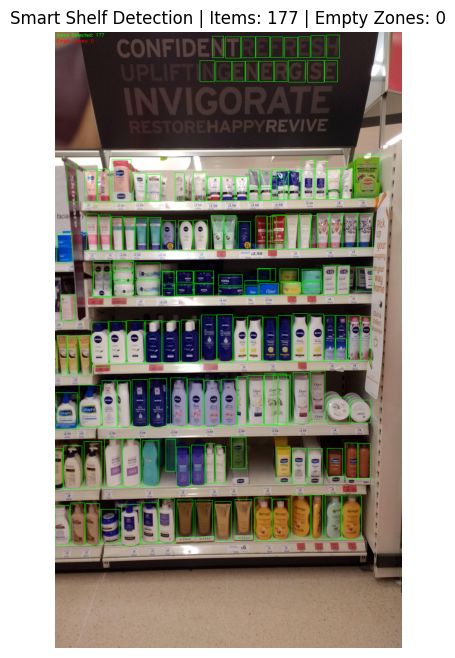

Items Detected: 177
Empty Zones: 0


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def detect_empty_zones(image_path, model, grid_rows=4, grid_cols=6, conf=0.25):
    """
    Custom empty zone detection logic.
    Divides shelf into grid, flags regions with no detections as EMPTY.

    Args:
        image_path: path to shelf image
        model: trained YOLOv8 model
        grid_rows: number of horizontal grid divisions
        grid_cols: number of vertical grid divisions
        conf: confidence threshold for detection
    """
    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Run YOLOv8 detection
    results = model(image_path, conf=conf)[0]
    boxes = results.boxes.xyxy.cpu().numpy()  # bounding boxes

    # Calculate grid cell size
    cell_h = h // grid_rows
    cell_w = w // grid_cols

    # Track which grid cells have detections
    grid_occupied = np.zeros((grid_rows, grid_cols), dtype=bool)

    for box in boxes:
        x1, y1, x2, y2 = box[:4]
        # Find center of each detected box
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        # Map to grid cell
        row = min(cy // cell_h, grid_rows - 1)
        col = min(cx // cell_w, grid_cols - 1)
        grid_occupied[row][col] = True

    # Draw results on image
    output = img_rgb.copy()
    item_count = len(boxes)
    empty_count = 0

    for row in range(grid_rows):
        for col in range(grid_cols):
            x1 = col * cell_w
            y1 = row * cell_h
            x2 = x1 + cell_w
            y2 = y1 + cell_h

            if not grid_occupied[row][col]:
                # RED = empty zone
                overlay = output.copy()
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), -1)
                output = cv2.addWeighted(overlay, 0.4, output, 0.6, 0)
                cv2.rectangle(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
                empty_count += 1

    # Draw detection bounding boxes in GREEN
    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])
        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Add text overlay
    cv2.putText(output, f'Items Detected: {item_count}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(output, f'Empty Zones: {empty_count}',
                (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    return output, item_count, empty_count


# ---- Test on a sample shelf image ----
best_model = YOLO(
    '/content/drive/MyDrive/SmartShelf_Project/smart_shelf/weights/best.pt'
)

# Pick a test image
test_img_dir = os.path.join(dataset.location, 'test', 'images')
test_img = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])

output, items, empty = detect_empty_zones(test_img, best_model)

plt.figure(figsize=(14, 8))
plt.imshow(output)
plt.title(f'Smart Shelf Detection | Items: {items} | Empty Zones: {empty}')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/SmartShelf_Project/detection_result.png',
            bbox_inches='tight')
plt.show()
print(f"Items Detected: {items}")
print(f"Empty Zones: {empty}")

In [ ]:
# Export trained model to formats compatible with Jetson Nano
best_model = YOLO(
    '/content/drive/MyDrive/SmartShelf_Project/smart_shelf/weights/best.pt'
)

# Export to ONNX format (works on Jetson Nano)
best_model.export(format='onnx', imgsz=640)
print("Model exported to ONNX format for Jetson Nano!")
print("Download best.pt and best.onnx from Google Drive for Phase 2")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/SmartShelf_Project/smart_shelf/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (56.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 327ms
Prepared 4 packages in 4.55s
Installed 4 packages in 332ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 6.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

# Verify your model is still there
import os
model_path = '/content/drive/MyDrive/SmartShelf_Project/smart_shelf-2/weights/best.pt'
if os.path.exists(model_path):
    print("✅ best.pt found! Ready to export.")
else:
    print("❌ Model not found - check path")

Mounted at /content/drive
Drive mounted!
✅ best.pt found! Ready to export.


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    '/content/drive/MyDrive/SmartShelf_Project/smart_shelf-2/weights/best.pt'
)

# Export with opset 19
best_model.export(
    format='onnx',
    imgsz=640,
    opset=19
)

print("✅ Done! Download best.onnx from Drive")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/SmartShelf_Project/smart_shelf-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in